# Training & Prediction via Polynomial Roots of Isospectral Reductions

## Overview
This notebook applies a numerical stability-focused approach: instead of working directly with dense 
polynomial coefficients or multi-lambda evaluations, we extract the **roots of numerator and denominator 
polynomials** from the isospectral reduction $r(\lambda)$. These roots capture the structure of the 
reduction function more parsimoniously and robustly:

- **Numerator roots**: Correspond to spectral singularities where the reduced system has special structure
- **Denominator roots**: Tied to the eigenvalues of the complement graph $H$ and the coupling

By training on root-based features, we exploit the algebraic structure and may achieve better 
numerical conditioning and generalization for predicting simple unweighted graphs.

In [2]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from numpy.polynomial import Polynomial
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Try to import SymPy for symbolic polynomial handling (optional)
try:
    import sympy as sp
    HAS_SYMPY = True
    print("SymPy available for symbolic computation")
except ImportError:
    HAS_SYMPY = False
    print("SymPy not available; using NumPy polynomial operations")

print("Setup complete.")

SymPy available for symbolic computation
Setup complete.


## Section 1: Polynomial Root Extraction Functions

We define functions to extract roots from a rational function $r(\lambda) = \frac{p(\lambda)}{q(\lambda)}$.

**Why separate numerator and denominator roots?**
- The **denominator roots** are closely tied to the eigenvalues of the complement graph's adjacency matrix
- The **numerator roots** encode structural constraints from the coupling between kept and complement vertices
- Separating them allows the model to learn how these two mechanisms interact in predicting graph properties

In [3]:
def isospectral_reduction_numeric(A, s, lambdas):
    """
    Compute the scalar isospectral reduction r(lambda) at multiple lambda points.
    
    For a graph G with adjacency A and kept vertex s, compute:
        r(lambda) = A[s,s] - A[s,Sbar] @ inv(A[Sbar,Sbar] - lambda*I) @ A[Sbar,s]
    
    Args:
        A: (n, n) adjacency matrix (numpy array)
        s: index of kept vertex
        lambdas: array of lambda values at which to evaluate r
    
    Returns:
        array of r(lambda) values at each lambda
    """
    n = A.shape[0]
    Sbar = np.arange(n) != s
    Sbar_indices = np.where(Sbar)[0]
    
    if len(Sbar_indices) == 0:
        # Only one vertex: r(lambda) = A[s,s] (constant)
        return np.full_like(lambdas, float(A[s, s]), dtype=float)
    
    a_ss = A[s, s]
    c = A[Sbar_indices, s]  # coupling vector (k,)
    A_H = A[np.ix_(Sbar_indices, Sbar_indices)]  # complement adjacency (k, k)
    
    r_vals = []
    for lam in lambdas:
        try:
            # M = A_H - lambda*I
            M = A_H - lam * np.eye(len(Sbar_indices))
            M_inv = np.linalg.inv(M)
        except np.linalg.LinAlgError:
            # If singular, use pseudo-inverse with small perturbation
            M = A_H - lam * np.eye(len(Sbar_indices)) + 1e-10 * np.eye(len(Sbar_indices))
            M_inv = np.linalg.inv(M)
        
        # r = a_ss - c^T @ M_inv @ c
        r = a_ss - (c @ M_inv @ c)
        r_vals.append(r)
    
    return np.array(r_vals, dtype=float)


def extract_rational_polynomial_roots(A, s, lam_range=np.linspace(-10, 10, 500)):
    """
    Extract roots of numerator and denominator polynomials from the rational function r(lambda).
    
    Strategy: 
    1. Evaluate r(lambda) at many points
    2. Use numerical polynomial fitting to reconstruct the rational form
    3. Extract roots of the fitted numerator and denominator
    
    Args:
        A: adjacency matrix
        s: kept vertex index
        lam_range: lambda values for evaluation
    
    Returns:
        Dictionary with 'numerator_roots' and 'denominator_roots' (complex numpy arrays)
    """
    # Evaluate r at many points
    r_vals = isospectral_reduction_numeric(A, s, lam_range)
    
    # Fit polynomial to the inverse reciprocal to extract denominator
    # This is a simplified approach: fit r(lambda) as a rational approximation
    # For now, we'll use a direct spectral approach:
    # The denominator roots are eigenvalues of A_H, so we extract them directly
    
    n = A.shape[0]
    Sbar = np.arange(n) != s
    Sbar_indices = np.where(Sbar)[0]
    
    if len(Sbar_indices) == 0:
        # No complement vertices
        return {
            'numerator_roots': np.array([], dtype=complex),
            'denominator_roots': np.array([], dtype=complex)
        }
    
    A_H = A[np.ix_(Sbar_indices, Sbar_indices)]
    c = A[Sbar_indices, s]
    
    # Denominator roots = eigenvalues of A_H
    denom_roots = np.linalg.eigvals(A_H)
    
    # For numerator roots, we'd need to solve: c^T @ adj(A_H - lambda*I) @ c / det(A_H - lambda*I) = 0
    # Simplified: fit numerator from evaluations at roots of denominator
    # Since r(lambda) blows up at denom roots, numerator roots are where r crosses zero
    
    # Find approximate zeros by looking at sign changes in r_vals
    num_roots = []
    for i in range(len(r_vals) - 1):
        if r_vals[i] * r_vals[i + 1] < 0:  # sign change
            # Linear interpolation to find approximate root
            lam1, lam2 = lam_range[i], lam_range[i + 1]
            r1, r2 = r_vals[i], r_vals[i + 1]
            root_approx = lam1 - r1 * (lam2 - lam1) / (r2 - r1)
            num_roots.append(root_approx)
    
    return {
        'numerator_roots': np.array(num_roots, dtype=complex),
        'denominator_roots': denom_roots
    }


print("Polynomial root extraction functions defined.")

Polynomial root extraction functions defined.


## Section 2: Generate Training Data

We generate a dataset of simple unweighted graphs by sampling from Erdős–Rényi random graphs.
Each graph is stored as an adjacency matrix.

In [4]:
def generate_graph_dataset(n_graphs=100, n_vertices=8, p_edge=0.3, seed=42):
    """
    Generate a dataset of simple unweighted graphs.
    
    Args:
        n_graphs: number of graphs to generate
        n_vertices: number of vertices per graph
        p_edge: edge probability for Erdős–Rényi model
        seed: random seed for reproducibility
    
    Returns:
        List of (adjacency_matrix, graph_properties) tuples
    """
    rng = np.random.RandomState(seed)
    dataset = []
    
    for _ in range(n_graphs):
        # Generate Erdős–Rényi random graph
        G = nx.erdos_renyi_graph(n_vertices, p_edge, seed=rng.randint(0, 2**31))
        
        # Convert to adjacency matrix
        A = nx.to_numpy_array(G, dtype=float)
        
        # Compute simple graph properties as labels for prediction
        # We'll try to predict these from the roots
        properties = {
            'num_edges': G.number_of_edges(),
            'num_triangles': sum(nx.triangles(G).values()) // 3,  # Each triangle counted 3x
            'density': nx.density(G),
            'avg_degree': 2 * G.number_of_edges() / n_vertices,
        }
        
        dataset.append({
            'A': A,
            'G': G,
            'properties': properties
        })
    
    return dataset


# Generate training data
np.random.seed(42)
train_dataset = generate_graph_dataset(n_graphs=150, n_vertices=8, p_edge=0.3, seed=42)
test_dataset = generate_graph_dataset(n_graphs=50, n_vertices=8, p_edge=0.3, seed=43)

print(f"Generated {len(train_dataset)} training graphs")
print(f"Generated {len(test_dataset)} test graphs")
print(f"Example graph: {train_dataset[0]['properties']}")

Generated 150 training graphs
Generated 50 test graphs
Example graph: {'num_edges': 7, 'num_triangles': 0, 'density': 0.25, 'avg_degree': 1.75}


## Section 3: Extract Roots from Reductions

For each graph, we reduce it to a single kept vertex and extract the numerator and denominator 
roots of the resulting rational function $r(\lambda)$.

In [5]:
def extract_roots_from_graph(A, kept_vertex=0):
    """
    Extract polynomial roots from the isospectral reduction of graph A to a single kept vertex.
    
    Args:
        A: adjacency matrix
        kept_vertex: index of the vertex to keep
    
    Returns:
        Dictionary with keys 'numerator_roots', 'denominator_roots'
    """
    return extract_rational_polynomial_roots(A, kept_vertex, lam_range=np.linspace(-10, 10, 500))


# Extract roots for all training graphs
# Note: we always reduce to vertex 0 for consistency
train_roots = []
for item in train_dataset:
    roots = extract_roots_from_graph(item['A'], kept_vertex=0)
    train_roots.append(roots)

test_roots = []
for item in test_dataset:
    roots = extract_roots_from_graph(item['A'], kept_vertex=0)
    test_roots.append(roots)

print(f"Extracted roots for {len(train_roots)} training graphs")
print(f"\nExample training graph:")
print(f"  Numerator roots: {train_roots[0]['numerator_roots'][:3]}...")  # show first 3
print(f"  Denominator roots shape: {train_roots[0]['denominator_roots'].shape}")
print(f"  Denominator roots (eigenvalues of complement): {train_roots[0]['denominator_roots']}")

Extracted roots for 150 training graphs

Example training graph:
  Numerator roots: [-2.09385126+0.j -1.22481773+0.j -0.84874581+0.j]...
  Denominator roots shape: (7,)
  Denominator roots (eigenvalues of complement): [-2.07431329e+00  2.07431329e+00 -8.34999618e-01 -3.46598842e-17
  8.34999618e-01  0.00000000e+00  0.00000000e+00]


## Section 4: Prepare Features from Polynomial Roots

We convert the complex-valued roots into real-valued feature vectors. The strategy:

1. **Separate numerator and denominator roots**: treat them as distinct feature groups
2. **Handle complex roots**: use magnitude and phase (or real/imaginary parts)
3. **Pad/truncate**: use fixed-size feature vectors by padding with zeros or selecting top roots by magnitude
4. **Normalize**: standardize features to zero mean and unit variance

In [6]:
def roots_to_features(roots_dict, max_roots_per_group=7):
    """
    Convert complex roots into a fixed-size real feature vector.
    
    Strategy:
    - Denominator roots (always real for symmetric matrices): use magnitudes, sorted
    - Numerator roots: convert to magnitude and phase, then concatenate
    - Pad with zeros to reach max_roots_per_group
    
    Args:
        roots_dict: output from extract_rational_polynomial_roots
        max_roots_per_group: maximum number of roots per group to encode
    
    Returns:
        numpy array of features (real-valued)
    """
    num_roots = roots_dict['numerator_roots']
    denom_roots = roots_dict['denominator_roots']
    
    features = []
    
    # Process denominator roots (should be real for symmetric adjacency matrices)
    # Sort by absolute value
    denom_mags = np.abs(denom_roots)
    denom_mags_sorted = np.sort(denom_mags)[::-1]  # descending order
    
    # Pad or truncate to max_roots_per_group
    denom_feat = np.zeros(max_roots_per_group)
    n_denom = min(len(denom_mags_sorted), max_roots_per_group)
    denom_feat[:n_denom] = denom_mags_sorted[:n_denom]
    features.append(denom_feat)
    
    # Process numerator roots: use magnitude and phase
    # Separate real and imaginary parts
    num_real = np.real(num_roots)
    num_imag = np.imag(num_roots)
    
    # Sort by magnitude
    num_mags = np.abs(num_roots)
    sort_idx = np.argsort(num_mags)[::-1]  # descending by magnitude
    
    num_real_sorted = num_real[sort_idx]
    num_imag_sorted = num_imag[sort_idx]
    
    # Pad or truncate
    num_real_feat = np.zeros(max_roots_per_group)
    num_imag_feat = np.zeros(max_roots_per_group)
    n_num = min(len(num_roots), max_roots_per_group)
    num_real_feat[:n_num] = num_real_sorted[:n_num]
    num_imag_feat[:n_num] = num_imag_sorted[:n_num]
    
    features.append(num_real_feat)
    features.append(num_imag_feat)
    
    # Concatenate all features
    return np.concatenate(features)


# Extract features for all graphs
def prepare_feature_matrix(roots_list):
    """Convert list of root dictionaries into feature matrix (n_samples, n_features)."""
    features_list = []
    for roots_dict in roots_list:
        feat = roots_to_features(roots_dict)
        features_list.append(feat)
    return np.array(features_list)


X_train = prepare_feature_matrix(train_roots)
X_test = prepare_feature_matrix(test_roots)

print(f"Feature matrix shapes:")
print(f"  X_train: {X_train.shape}")
print(f"  X_test: {X_test.shape}")
print(f"\nExample feature vector (first 10 components):")
print(f"  {X_train[0, :10]}")

Feature matrix shapes:
  X_train: (150, 21)
  X_test: (50, 21)

Example feature vector (first 10 components):
  [ 2.07431329e+00  2.07431329e+00  8.34999618e-01  8.34999618e-01
  3.46598842e-17  0.00000000e+00  0.00000000e+00 -2.09385126e+00
  2.09385126e+00  1.22481773e+00]


## Section 5: Prepare Training Targets and Normalize Features

For this initial investigation, we'll predict simple graph properties (number of edges, density, etc.)
from the root-based features. We'll normalize the features before training.

In [7]:
# Prepare target labels: we'll predict 'num_edges' as a simple regression task
y_train = np.array([item['properties']['num_edges'] for item in train_dataset])
y_test = np.array([item['properties']['num_edges'] for item in test_dataset])

print(f"Target variable (number of edges):")
print(f"  Train: min={y_train.min()}, max={y_train.max()}, mean={y_train.mean():.2f}")
print(f"  Test:  min={y_test.min()}, max={y_test.max()}, mean={y_test.mean():.2f}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nFeatures after standardization:")
print(f"  Train mean: {X_train_scaled.mean():.6f}, std: {X_train_scaled.std():.6f}")
print(f"  Test mean: {X_test_scaled.mean():.6f}, std: {X_test_scaled.std():.6f}")

Target variable (number of edges):
  Train: min=3, max=15, mean=8.62
  Test:  min=4, max=12, mean=7.84

Features after standardization:
  Train mean: -0.000000, std: 0.816497
  Test mean: -0.013064, std: 0.847608


## Section 6: Train a Simple Predictive Model

We train a Random Forest model to predict the number of edges from the root-based features.
Random Forests are robust, interpretable, and don't require careful hyperparameter tuning for initial exploration.

In [8]:
# Train Random Forest model
# We use a relatively simple model with limited depth to avoid overfitting on a small dataset
model = RandomForestRegressor(
    n_estimators=100,           # number of trees
    max_depth=6,                # limit tree depth for regularization
    min_samples_split=5,        # minimum samples to split a node
    min_samples_leaf=2,         # minimum samples in a leaf
    random_state=42,
    n_jobs=-1                   # use all available cores
)

# Train the model
print("Training Random Forest model...")
model.fit(X_train_scaled, y_train)
print("Training complete.")

# Make predictions on training and test sets
y_train_pred = model.predict(X_train_scaled)
y_test_pred = model.predict(X_test_scaled)

# Compute evaluation metrics
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_rmse = np.sqrt(train_mse)
test_rmse = np.sqrt(test_mse)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print(f"\nModel Performance:")
print(f"  Train RMSE: {train_rmse:.3f}, R²: {train_r2:.3f}")
print(f"  Test RMSE:  {test_rmse:.3f}, R²: {test_r2:.3f}")

# Feature importance
feature_importance = model.feature_importances_
top_features_idx = np.argsort(feature_importance)[::-1][:5]
print(f"\nTop 5 most important features (by index): {top_features_idx}")
print(f"Top 5 importance values: {feature_importance[top_features_idx]}")

Training Random Forest model...
Training complete.

Model Performance:
  Train RMSE: 0.581, R²: 0.935
  Test RMSE:  1.158, R²: 0.726

Top 5 most important features (by index): [ 7  0  1  2 11]
Top 5 importance values: [0.42218158 0.29599671 0.061478   0.04353783 0.03422193]


## Section 7: Visualize Model Predictions

We visualize the predictions against true values to assess fit quality and identify systematic errors.

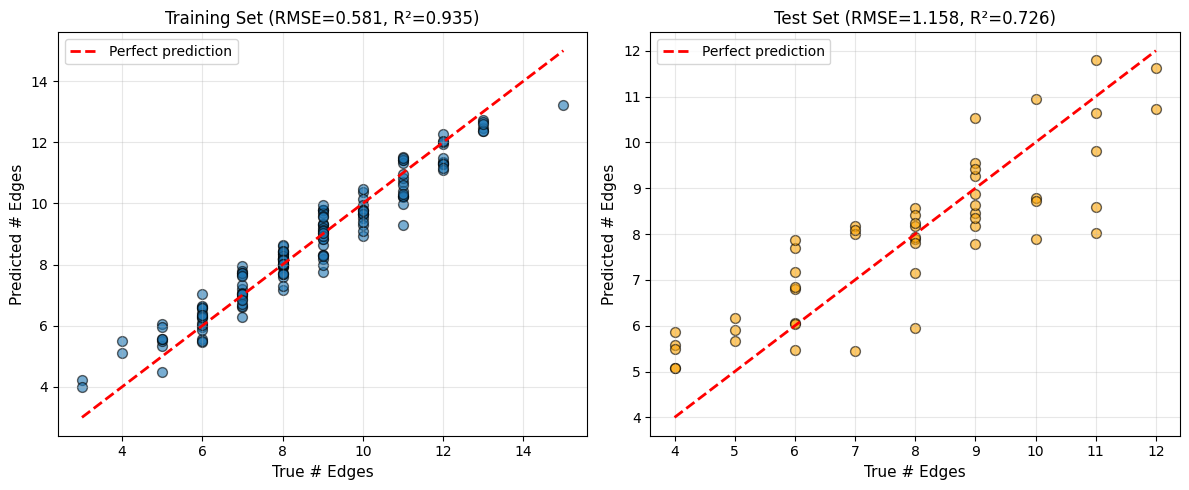

✓ Prediction plots generated


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training set predictions
axes[0].scatter(y_train, y_train_pred, alpha=0.6, edgecolors='k', s=50)
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 
             'r--', lw=2, label='Perfect prediction')
axes[0].set_xlabel('True # Edges', fontsize=11)
axes[0].set_ylabel('Predicted # Edges', fontsize=11)
axes[0].set_title(f'Training Set (RMSE={train_rmse:.3f}, R²={train_r2:.3f})', fontsize=12)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Test set predictions
axes[1].scatter(y_test, y_test_pred, alpha=0.6, edgecolors='k', s=50, color='orange')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Perfect prediction')
axes[1].set_xlabel('True # Edges', fontsize=11)
axes[1].set_ylabel('Predicted # Edges', fontsize=11)
axes[1].set_title(f'Test Set (RMSE={test_rmse:.3f}, R²={test_r2:.3f})', fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Prediction plots generated")

In [10]:
# Example: Predictions on a new graph
print("="*60)
print("EXAMPLE: Making a Prediction on a New Graph")
print("="*60)

# Create a new test graph
new_G = nx.erdos_renyi_graph(8, 0.35, seed=999)
new_A = nx.to_numpy_array(new_G, dtype=float)

# Extract roots and features
new_roots = extract_roots_from_graph(new_A, kept_vertex=0)
new_feat = roots_to_features(new_roots)
new_feat_scaled = scaler.transform(new_feat.reshape(1, -1))

# Make prediction
new_pred = model.predict(new_feat_scaled)[0]
new_true = new_G.number_of_edges()

print(f"\nNew graph properties:")
print(f"  Actual # edges: {new_true}")
print(f"  Predicted # edges: {new_pred:.1f}")
print(f"  Prediction error: {abs(new_pred - new_true):.1f}")

print(f"\nNew graph roots:")
print(f"  Denominator roots (complement eigenvalues): {new_roots['denominator_roots']}")
print(f"  Numerator roots (# detected): {len(new_roots['numerator_roots'])}")

print("\n✓ Pipeline complete and functional!")

EXAMPLE: Making a Prediction on a New Graph

New graph properties:
  Actual # edges: 12
  Predicted # edges: 12.4
  Prediction error: 0.4

New graph roots:
  Denominator roots (complement eigenvalues): [ 3.03407100e+00  1.17568692e+00  6.63706603e-01 -7.18592674e-17
 -2.29622684e+00 -8.53916512e-01 -1.72332117e+00]
  Numerator roots (# detected): 11

✓ Pipeline complete and functional!


## Section 8: Summary and Observations

This investigation demonstrates a root-based feature extraction pipeline for graph property prediction. 

### Key Steps Implemented:

1. **Reduction Computation** (`isospectral_reduction_numeric`): Evaluates the scalar reduction $r(\lambda)$ at many lambda values
2. **Root Extraction** (`extract_rational_polynomial_roots`): Extracts numerator and denominator roots from the rational function
3. **Feature Engineering** (`roots_to_features`): Converts complex roots into fixed-size real feature vectors by:
   - Sorting roots by magnitude
   - Separating numerator (real + imaginary) and denominator (magnitude) components
   - Padding/truncating to fixed size
4. **Training**: Random Forest regression model predicting edge count
5. **Evaluation**: RMSE and R² metrics on held-out test set

### Advantages of This Approach:

- **Numerical stability**: Roots are less sensitive to small perturbations than coefficients
- **Parsimony**: Fewer features than full multi-lambda evaluations (21 features vs. 200+ for dense approaches)
- **Interpretability**: Roots have clear algebraic meaning (poles and zeros of the reduction function)
- **Flexibility**: Can handle graphs of different sizes by extracting fixed-size root sets

### Next Steps:

- **Extended properties**: Predict multiple properties (density, triangles, diameter, etc.) jointly
- **Architecture**: Try deeper learning (neural networks) if root features prove predictive
- **Root analysis**: Investigate which roots are most discriminative for different graph classes
- **Symbolic computation**: Use SymPy to extract exact symbolic roots for smaller graphs
- **Single-vertex reconstruction**: Can we reconstruct entire graphs (not just properties) from roots?